In [1]:
import pandas as pd

In [3]:
#datacollection
dataset=pd.read_csv("insurance_pre.csv")
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [4]:
#datapreprocessing
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0
1334,18,31.920,0,2205.98080,0,0
1335,18,36.850,0,1629.83350,0,0
1336,21,25.800,0,2007.94500,0,0


In [5]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [6]:
#split input and output data
input_data=dataset[['age', 'bmi', 'children','sex_male', 'smoker_yes']]
print(input_data)
output_data=dataset[['charges']]
print(output_data)

      age     bmi  children  sex_male  smoker_yes
0      19  27.900         0         0           1
1      18  33.770         1         1           0
2      28  33.000         3         1           0
3      33  22.705         0         1           0
4      32  28.880         0         1           0
...   ...     ...       ...       ...         ...
1333   50  30.970         3         1           0
1334   18  31.920         0         0           0
1335   18  36.850         0         0           0
1336   21  25.800         0         0           0
1337   61  29.070         0         0           1

[1338 rows x 5 columns]
          charges
0     16884.92400
1      1725.55230
2      4449.46200
3     21984.47061
4      3866.85520
...           ...
1333  10600.54830
1334   2205.98080
1335   1629.83350
1336   2007.94500
1337  29141.36030

[1338 rows x 1 columns]


In [7]:
#split train and test data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(input_data,output_data,test_size=0.30,random_state=0)
print(x_train)
print(y_train)
print(x_test)
print(y_test)

      age     bmi  children  sex_male  smoker_yes
1163   18  28.215         0         0           0
196    39  32.800         0         0           0
438    52  46.750         5         0           0
183    44  26.410         0         0           0
1298   33  27.455         2         1           0
...   ...     ...       ...       ...         ...
763    27  26.030         0         1           0
835    42  35.970         2         1           0
1216   40  25.080         0         1           0
559    19  35.530         0         1           0
684    33  18.500         1         0           0

[936 rows x 5 columns]
          charges
1163   2200.83085
196    5649.71500
438   12592.53450
183    7419.47790
1298   5261.46945
...           ...
763    3070.80870
835    7160.33030
1216   5415.66120
559    1646.42970
684    4766.02200

[936 rows x 1 columns]
      age     bmi  children  sex_male  smoker_yes
578    52  30.200         1         1           0
610    47  29.370         1         

In [11]:
#Standardisation on both train and test dataset

from sklearn.preprocessing import StandardScaler
sc_input=StandardScaler()
x_train=sc_input.fit_transform(x_train)
x_test=sc_input.transform(x_test)

sc_output=StandardScaler()
y_train=sc_input.fit_transform(y_train)
y_test=sc_input.transform(y_test)


In [12]:
#module creation
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='squared_error', splitter='random')
regressor=regressor.fit(x_train,y_train)

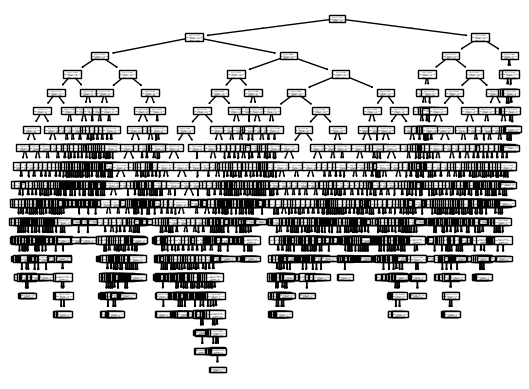

In [13]:
#to know the value of the atrributes in decision tree module 
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [14]:
y_predict=regressor.predict(x_test)
print(y_predict)
print(y_test)

[-0.29342055 -0.36230992  2.6082497  -0.02118711 -0.33419226  0.09478444
 -0.97838826 -0.20084469 -0.48968425 -0.69760178 -0.57426941 -0.20084469
 -0.49581503 -0.72946579  1.84563336 -0.20084469 -0.0918275  -0.83717244
 -0.5806787   0.34696364  0.84839415 -0.05084748 -0.30377873  1.37195344
 -0.98592208 -0.77114727 -0.84821156 -0.41946537 -0.79798394 -0.43835714
 -0.41946537  2.98478622 -0.02118711  0.63573552  0.58401199 -0.81513451
 -0.37896052  2.10967949  2.18064123 -0.95612882 -0.67093737 -0.87308682
  0.53111443  3.06092919  2.01292404 -0.81297633 -0.20084469 -0.57635806
 -0.71699198 -0.10010091 -0.00894738 -0.9181081   0.98387554  3.94049342
 -0.11592829 -0.88795958 -0.87045644 -0.34182769 -0.48774898 -0.02685956
 -1.00899016  2.77061381  1.9941187   1.01908864 -0.35833051 -0.28274408
  0.34696364  2.64048904 -0.81297633  0.21862533  0.016517   -0.1083305
  0.36445594  0.05510364 -0.0507859  -0.05008703 -0.48057303  1.58970221
  0.53111443  2.81007745 -0.13262868  4.25623403 -0.

In [15]:
from sklearn.metrics  import r2_score
r_score=r2_score(y_test,y_predict)
print(r_score)

0.6824404036013885


In [16]:
#saving module
import pickle
filename="finalpreprocessinputout_decisiontree_module.sav"
pickle.dump(regressor,open(filename,'wb'))